# Proyecto final - Forecasting de volumen de trafico

**Series temporales con Machine Learning, modelo estadistico y Deep Learning**

Este notebook usa el mismo dataset y la misma transformacion del notebook original para comparar resultados. Se implementan tres modelos de categorias distintas:

- Random Forest, categoria Machine Learning.
- ETS semanal, categoria estadistica.
- LSTM, categoria Deep Learning.

El objetivo es pronosticar el volumen promedio diario de trafico vehicular en la autopista I-94.

## 1) Imports y configuracion

In [1]:
from pathlib import Path
import shutil
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 100)

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Directorio del proyecto:", ROOT)

torch.manual_seed(SEED)
torch.set_num_threads(1)
torch.backends.mkldnn.enabled = False

Directorio del proyecto: C:\Users\ACER PREDATOR\Desktop\series proyecto final


## 2) Carga y preprocesamiento del dataset

Se usa `anshtanwar/metro-interstate-traffic-volume`. Si el archivo ya existe en `data/`, se usa la copia local; si no, se descarga con KaggleHub.

In [2]:
DATASET_HANDLE = "anshtanwar/metro-interstate-traffic-volume"
TARGET_FILE = "Metro_Interstate_Traffic_Volume.csv"

local_csv = DATA_DIR / TARGET_FILE
if local_csv.exists():
    csv_path = local_csv
else:
    path = Path(kagglehub.dataset_download(DATASET_HANDLE))
    csv_path = path / TARGET_FILE
    if not csv_path.exists():
        matches = list(path.rglob(TARGET_FILE))
        if not matches:
            raise FileNotFoundError(f"No se encontro {TARGET_FILE}")
        csv_path = matches[0]
    shutil.copy2(csv_path, local_csv)
    csv_path = local_csv

raw = pd.read_csv(csv_path)
raw["date_time"] = pd.to_datetime(raw["date_time"], format="%d-%m-%Y %H:%M", errors="coerce")
raw = raw.dropna(subset=["date_time"]).copy()

hourly = (
    raw.rename(columns={"date_time": "ds", "traffic_volume": "y"})[["ds", "y"]]
    .groupby("ds", as_index=True)["y"]
    .mean()
    .to_frame()
    .sort_index()
)

y = hourly["y"].resample("D").mean().ffill().bfill().rename("traffic_volume_promedio_diario")
y.to_frame().reset_index().rename(columns={"ds": "date", "traffic_volume_promedio_diario": "traffic_volume"}).to_csv(
    DATA_DIR / "traffic_volume_daily.csv", index=False
)

print("Archivo usado:", csv_path)
print("Rango temporal:", y.index.min().date(), "->", y.index.max().date())
print("Observaciones diarias:", len(y))
display(y.head().to_frame())

Archivo usado: C:\Users\ACER PREDATOR\Desktop\series proyecto final\data\Metro_Interstate_Traffic_Volume.csv
Rango temporal: 2012-10-02 -> 2018-09-30
Observaciones diarias: 2190


,traffic_volume_promedio_diario
ds,
2012-10-02,4219.266667
2012-10-03,3317.250000
2012-10-04,3747.458333
2012-10-05,4242.545455
2012-10-06,3256.956522


## 3) Analisis exploratorio de datos

Se revisan la serie completa, el ultimo anio, el promedio mensual y el patron por dia de semana.

Resumen estadistico:


,count,mean,std,min,25%,50%,75%,max
y,2190.0,2904.662787,1068.171637,277.25,2501.479167,3356.267857,3687.802083,5263.25


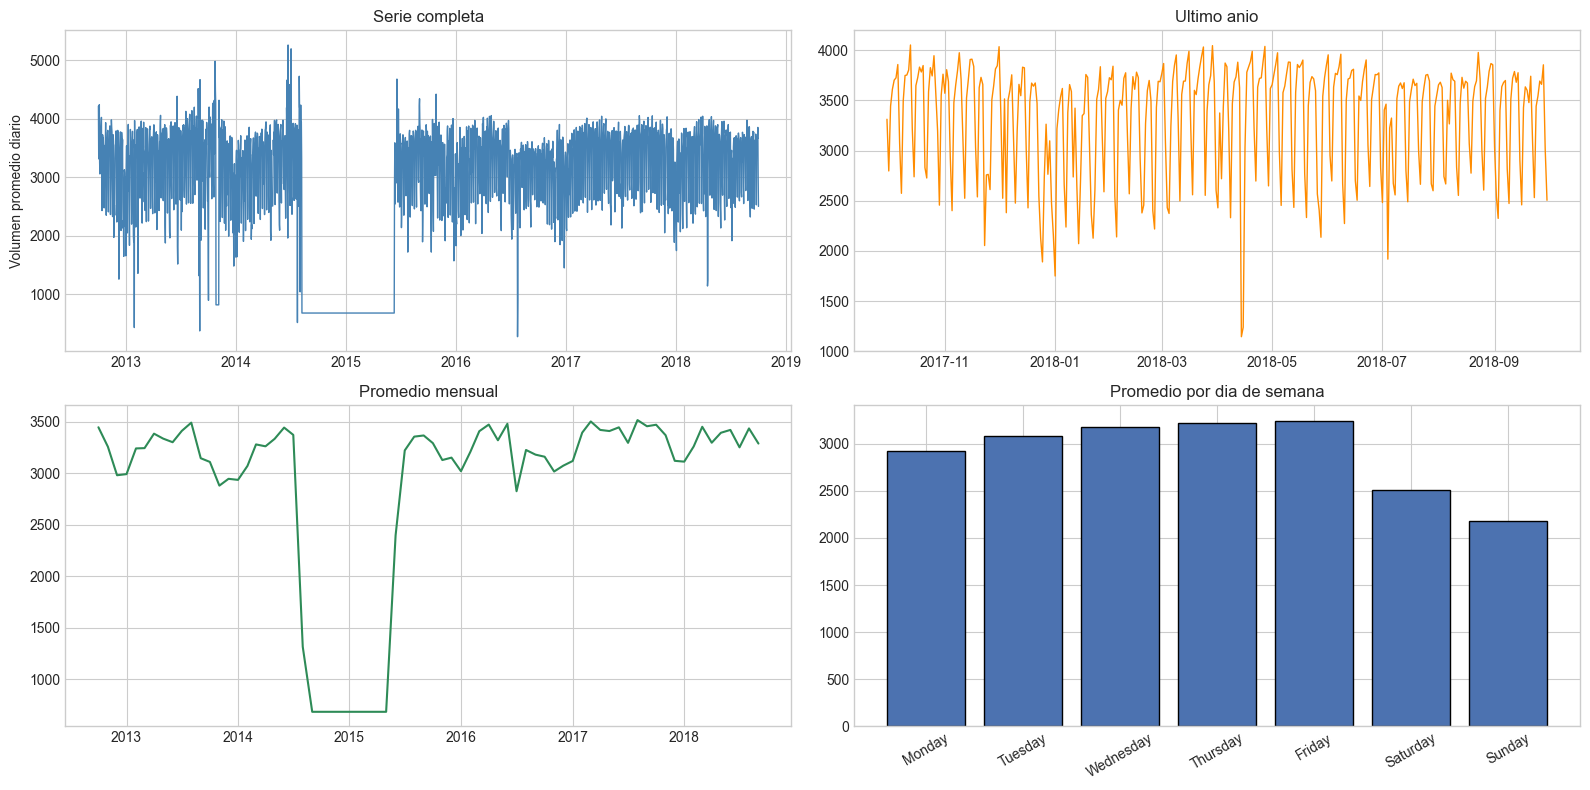

In [3]:
eda = pd.DataFrame({"y": y})
eda["weekday"] = eda.index.day_name()
monthly = y.resample("MS").mean()

print("Resumen estadistico:")
display(eda["y"].describe().to_frame().T)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.ravel()
axes[0].plot(y.index, y.values, color="steelblue", linewidth=1)
axes[0].set_title("Serie completa")
axes[0].set_ylabel("Volumen promedio diario")

last_year = y.index.max() - pd.Timedelta(days=365)
axes[1].plot(y.loc[y.index >= last_year].index, y.loc[y.index >= last_year].values, color="darkorange", linewidth=1)
axes[1].set_title("Ultimo anio")

axes[2].plot(monthly.index, monthly.values, color="seagreen", linewidth=1.5)
axes[2].set_title("Promedio mensual")

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_mean = eda.groupby("weekday")["y"].mean().reindex(weekday_order)
axes[3].bar(weekday_mean.index, weekday_mean.values, color="#4c72b0", edgecolor="black")
axes[3].set_title("Promedio por dia de semana")
axes[3].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_serie_original_eda.png", dpi=160, bbox_inches="tight")
plt.show()

## 4) Split temporal y politica anti-leakage

Se mantiene el mismo split del notebook original. El test final no se usa para seleccionar modelos.

Serie usada: 2012-10-02 -> 2018-09-30 | 2190 dias
Train: 2012-10-02 -> 2018-08-16 | 2145
Test: 2018-08-17 -> 2018-09-30 | 45


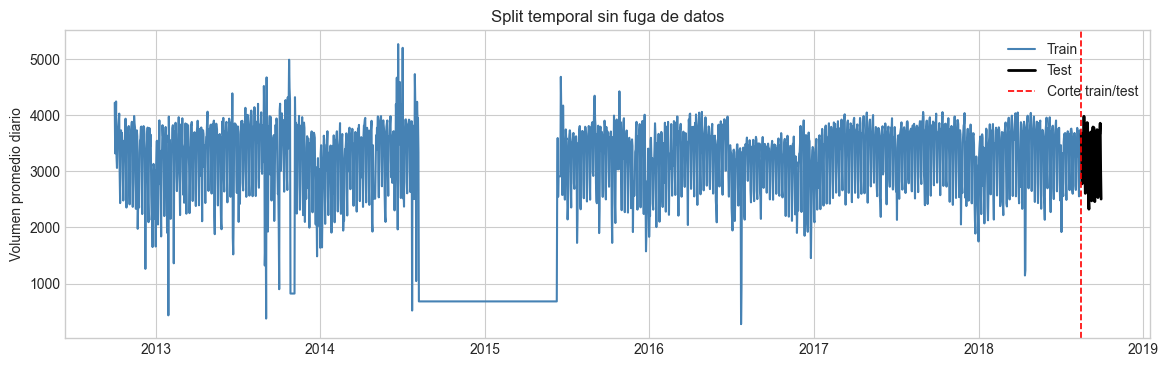

In [4]:
TEST_SIZE = 45
MAX_HISTORY = 2190

y_used = y.iloc[-MAX_HISTORY:].copy() if len(y) > MAX_HISTORY else y.copy()
y_train = y_used.iloc[:-TEST_SIZE].copy()
y_test = y_used.iloc[-TEST_SIZE:].copy()

print("Serie usada:", y_used.index.min().date(), "->", y_used.index.max().date(), "|", len(y_used), "dias")
print("Train:", y_train.index.min().date(), "->", y_train.index.max().date(), "|", len(y_train))
print("Test:", y_test.index.min().date(), "->", y_test.index.max().date(), "|", len(y_test))

plt.figure(figsize=(14, 4))
plt.plot(y_train.index, y_train.values, label="Train", color="steelblue")
plt.plot(y_test.index, y_test.values, label="Test", color="black", linewidth=2)
plt.axvline(y_train.index[-1], color="red", linestyle="--", linewidth=1.2, label="Corte train/test")
plt.title("Split temporal sin fuga de datos")
plt.ylabel("Volumen promedio diario")
plt.legend()
plt.savefig(FIGURES_DIR / "notebook_split_temporal.png", dpi=160, bbox_inches="tight")
plt.show()

## 5) Seleccion por backtesting temporal

Las tablas siguientes fueron generadas con `scripts/run_analysis.py` usando este mismo dataset, split y politica anti-leakage. Se cargan para evitar repetir el backtesting pesado dentro de Jupyter.

Mejor ventana Random Forest: todo_historico


,window,folds,mae_mean,mae_std,rmse_mean,mape_mean,n_train_mean
0,todo_historico,6,217.294136,117.872550,335.188705,9.235688,2063.5
1,730_dias,6,230.154346,146.761864,346.557190,9.482053,730.0
2,365_dias,6,235.173253,147.020021,350.499279,9.848275,365.0
3,180_dias,6,245.790731,127.967513,366.229469,9.921365,180.0


Mejor conjunto de lags Random Forest: 28_dias


,lags,folds,mae_mean,mae_std,rmse_mean,mape_mean
0,28_dias,6,214.160994,116.611449,336.192624,9.201281
1,14_dias,6,221.381870,123.624270,339.181068,9.148319
2,7_dias,6,226.957898,132.497461,324.942943,9.390538
3,hibrido_semanal,6,264.499905,193.881160,401.338181,10.642049


Mejor configuracion ETS: ETS_NA


,model,folds,mae_mean,mae_std,rmse_mean,mape_mean,trend,damped_trend,seasonal,seasonal_periods
0,ETS_NA,6,240.009465,151.620736,340.781785,9.724073,none,False,add,7
1,ETS_DA,6,240.040131,151.541907,340.881930,9.725036,add,True,add,7
2,ETS_AA,6,240.048380,152.114776,340.666261,9.719874,add,False,add,7


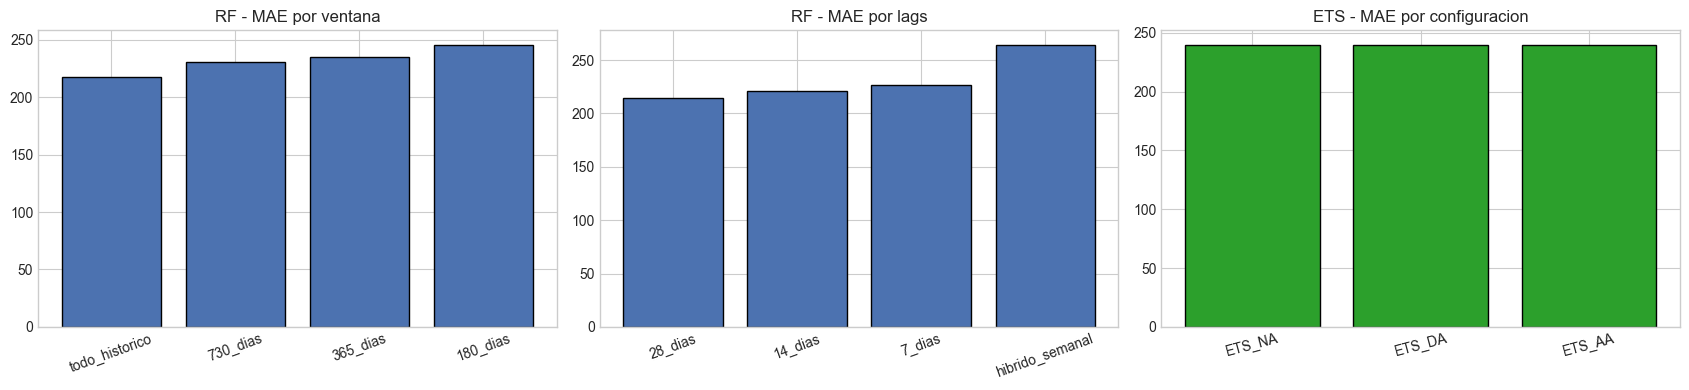

In [5]:
res_window = pd.read_csv(RESULTS_DIR / "backtesting_rf_ventanas.csv")
res_lags = pd.read_csv(RESULTS_DIR / "backtesting_rf_lags.csv")
res_ets = pd.read_csv(RESULTS_DIR / "backtesting_ets.csv")

best_window_label = res_window.sort_values("mae_mean").iloc[0]["window"]
best_lag_label = res_lags.sort_values("mae_mean").iloc[0]["lags"]
best_ets_label = res_ets.sort_values("mae_mean").iloc[0]["model"]

print("Mejor ventana Random Forest:", best_window_label)
display(res_window)
print("Mejor conjunto de lags Random Forest:", best_lag_label)
display(res_lags)
print("Mejor configuracion ETS:", best_ets_label)
display(res_ets)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].bar(res_window["window"], res_window["mae_mean"], color="#4c72b0", edgecolor="black")
axes[0].set_title("RF - MAE por ventana")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(res_lags["lags"], res_lags["mae_mean"], color="#4c72b0", edgecolor="black")
axes[1].set_title("RF - MAE por lags")
axes[1].tick_params(axis="x", rotation=20)
axes[2].bar(res_ets["model"], res_ets["mae_mean"], color="#2ca02c", edgecolor="black")
axes[2].set_title("ETS - MAE por configuracion")
axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_backtesting_resumen.png", dpi=160, bbox_inches="tight")
plt.show()

## 6) Funciones de metricas y modelos

In [6]:
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mape": 100 * np.mean(np.abs(y_true - y_pred) / np.maximum(np.abs(y_true), 1e-9)),
    }


def add_calendar_features(df):
    idx = df.index
    df["dow"] = idx.dayofweek
    df["month"] = idx.month
    df["doy_sin"] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * idx.dayofyear / 365.25)
    return df


def make_supervised_log(series, lags):
    z = np.log1p(series.astype(float))
    frame = pd.DataFrame(index=series.index)
    for lag in sorted(set(lags)):
        frame[f"lag_{lag}"] = z.shift(lag)
    frame = add_calendar_features(frame)
    frame["target_log"] = z.values
    return frame.dropna()


def recursive_forecast_rf(train_series, steps, lags, rf_params):
    supervised = make_supervised_log(train_series, lags)
    X = supervised.drop(columns=["target_log"])
    y_log = supervised["target_log"]

    model = RandomForestRegressor(random_state=SEED, n_jobs=1, **rf_params)
    model.fit(X, y_log)

    history = train_series.copy()
    history_log = list(np.log1p(history.values.astype(float)))
    preds = []

    for _ in range(steps):
        next_date = history.index[-1] + pd.Timedelta(days=1)
        row = {f"lag_{lag}": float(history_log[-lag]) for lag in lags}
        row["dow"] = next_date.dayofweek
        row["month"] = next_date.month
        row["doy_sin"] = np.sin(2 * np.pi * next_date.dayofyear / 365.25)
        row["doy_cos"] = np.cos(2 * np.pi * next_date.dayofyear / 365.25)
        row_df = pd.DataFrame([row], index=[next_date], columns=X.columns)
        pred_log = float(model.predict(row_df)[0])
        pred = max(np.expm1(pred_log), 0.0)
        preds.append(pred)
        history = pd.concat([history, pd.Series([pred], index=[next_date])])
        history_log.append(pred_log)

    return np.array(preds), model



class LSTMForecaster(nn.Module):
    def __init__(self, hidden_size=24, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


def make_lstm_dataset(train_series, seq_len):
    z = np.log1p(train_series.astype(float).values)
    mean = float(z.mean())
    std = float(z.std() + 1e-8)
    z_scaled = (z - mean) / std

    X, y_target = [], []
    for i in range(seq_len, len(z_scaled)):
        X.append(z_scaled[i - seq_len : i])
        y_target.append(z_scaled[i])

    X = torch.tensor(np.asarray(X), dtype=torch.float32).unsqueeze(-1)
    y_target = torch.tensor(np.asarray(y_target), dtype=torch.float32)
    return X, y_target, mean, std, list(z_scaled)


def recursive_forecast_lstm(train_series, steps, seq_len=28, epochs=35):
    X, y_target, mean, std, history_scaled = make_lstm_dataset(train_series, seq_len)

    model = LSTMForecaster(hidden_size=24, num_layers=1)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y_target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    model.eval()
    preds = []
    with torch.no_grad():
        for _ in range(steps):
            x_next = torch.tensor(history_scaled[-seq_len:], dtype=torch.float32).view(1, seq_len, 1)
            pred_scaled = float(model(x_next).item())
            history_scaled.append(pred_scaled)
            pred_log = pred_scaled * std + mean
            pred = max(np.expm1(pred_log), 0.0)
            preds.append(pred)

    return np.array(preds), model

def forecast_ets(train_series, steps, config):
    model = ExponentialSmoothing(
        train_series.astype(float),
        trend=config["trend"],
        damped_trend=bool(config["damped_trend"]),
        seasonal=config["seasonal"],
        seasonal_periods=7,
        initialization_method="estimated",
    )
    fit = model.fit(optimized=True, use_brute=False)
    pred = fit.forecast(steps)
    return np.maximum(np.asarray(pred, dtype=float), 0.0)

## 7) Entrenamiento final y evaluacion en test holdout

Se entrenan los tres modelos con las configuraciones seleccionadas y se evalua sobre los 45 dias finales. El LSTM usa secuencias de 28 dias del mismo target diario para una comparacion Deep Learning directa.

In [7]:
RF_PARAMS = {"n_estimators": 160, "max_depth": 16, "min_samples_leaf": 3}
LAG_CANDIDATES = {
    "7_dias": list(range(1, 8)),
    "14_dias": list(range(1, 15)),
    "28_dias": list(range(1, 29)),
    "hibrido_semanal": list(range(1, 15)) + [21, 28, 35, 42, 49, 56],
}
WINDOW_CANDIDATES = {"180_dias": 180, "365_dias": 365, "730_dias": 730, "todo_historico": None}
ETS_CANDIDATES = {
    "ETS_AA": {"trend": "add", "damped_trend": False, "seasonal": "add"},
    "ETS_NA": {"trend": None, "damped_trend": False, "seasonal": "add"},
    "ETS_DA": {"trend": "add", "damped_trend": True, "seasonal": "add"},
}

best_window = WINDOW_CANDIDATES[best_window_label]
best_lags = LAG_CANDIDATES[best_lag_label]
best_ets_config = ETS_CANDIDATES[best_ets_label]

y_train_rf = y_train.copy() if best_window is None else y_train.iloc[-best_window:].copy()
y_pred_rf, final_rf = recursive_forecast_rf(y_train_rf, len(y_test), best_lags, RF_PARAMS)
y_pred_ets = forecast_ets(y_train, len(y_test), best_ets_config)
y_pred_lstm, final_lstm = recursive_forecast_lstm(y_train_rf, len(y_test), seq_len=28, epochs=35)

final_metrics = pd.DataFrame([
    {"modelo": "Random Forest", "categoria": "Machine Learning", **metrics(y_test.values, y_pred_rf)},
    {"modelo": "ETS semanal", "categoria": "Estadistico", **metrics(y_test.values, y_pred_ets)},
    {"modelo": "LSTM", "categoria": "Deep Learning", **metrics(y_test.values, y_pred_lstm)},
]).sort_values("mae").reset_index(drop=True)

res_test = pd.DataFrame({
    "date": y_test.index,
    "y_real": y_test.values,
    "random_forest": y_pred_rf,
    "ets_semanal": y_pred_ets,
    "lstm": y_pred_lstm,
    "error_abs_random_forest": np.abs(y_test.values - y_pred_rf),
    "error_abs_ets_semanal": np.abs(y_test.values - y_pred_ets),
    "error_abs_lstm": np.abs(y_test.values - y_pred_lstm),
})

display(final_metrics)
display(res_test.head())

final_metrics.to_csv(RESULTS_DIR / "notebook_metricas_modelos.csv", index=False)
res_test.to_csv(RESULTS_DIR / "notebook_predicciones_test.csv", index=False)

,modelo,categoria,mae,rmse,mape
0,ETS semanal,Estadistico,115.036872,200.285922,3.792499
1,Random Forest,Machine Learning,116.025321,206.825548,3.886307
2,LSTM,Deep Learning,450.244362,487.551966,14.036915


,date,y_real,random_forest,ets_semanal,lstm,error_abs_random_forest,error_abs_ets_semanal,error_abs_lstm
0,2018-08-17,3672.541667,3718.316742,3783.395675,3312.296842,45.775075,110.854009,360.244825
1,2018-08-18,3071.458333,2861.245694,2885.098134,3278.549112,210.212640,186.360200,207.090779
2,2018-08-19,2774.916667,2596.958099,2577.631678,3255.167575,177.958568,197.284989,480.250909
3,2018-08-20,3492.250000,3468.594553,3442.316432,3239.738841,23.655447,49.933568,252.511159
4,2018-08-21,3637.291667,3623.208458,3580.947520,3230.465064,14.083209,56.344146,406.826603


## 8) Visualizaciones de prediccion y residuales

Se comparan los tres modelos sobre el mismo test holdout y se revisan sus residuos.

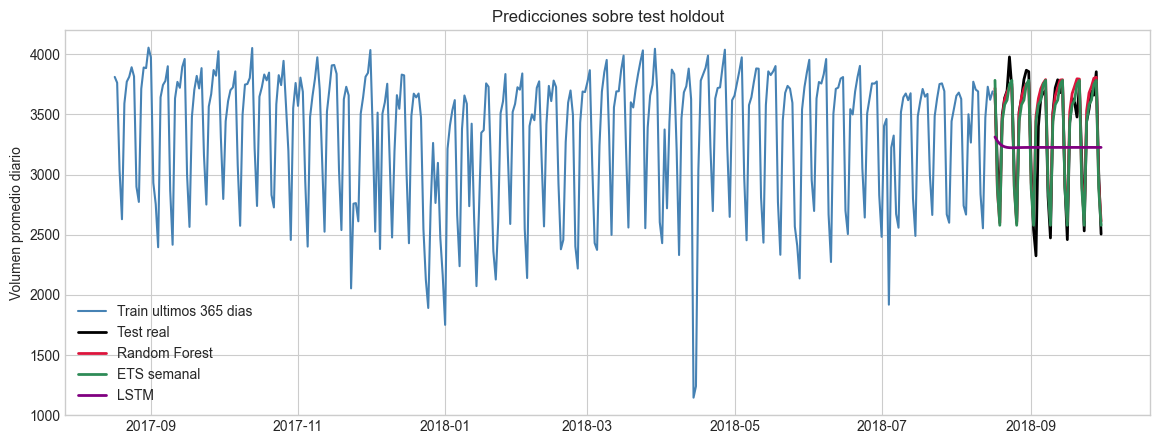

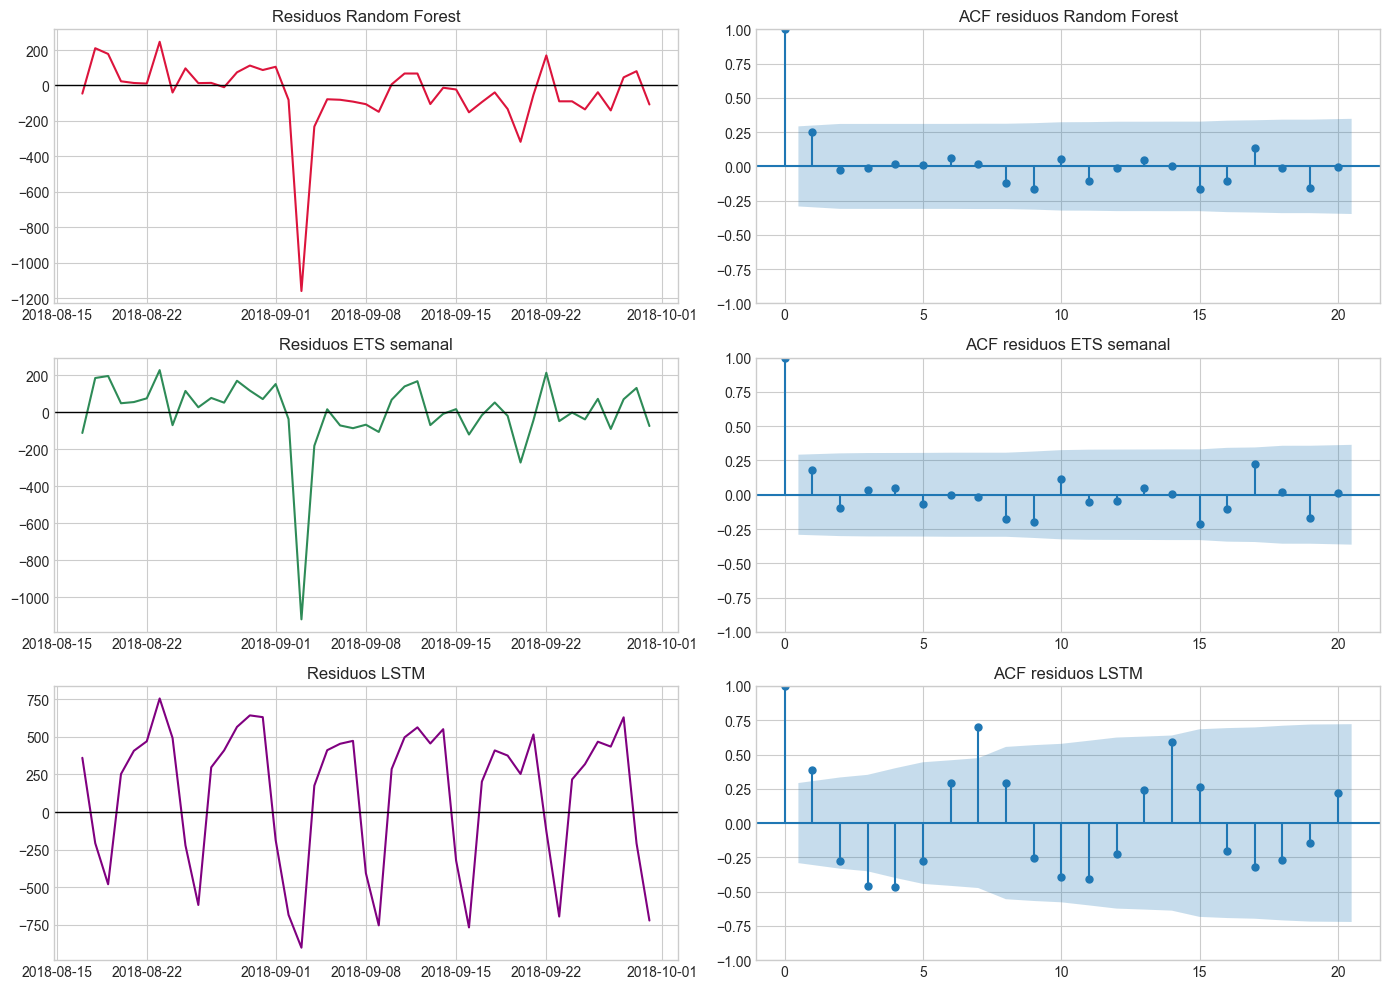

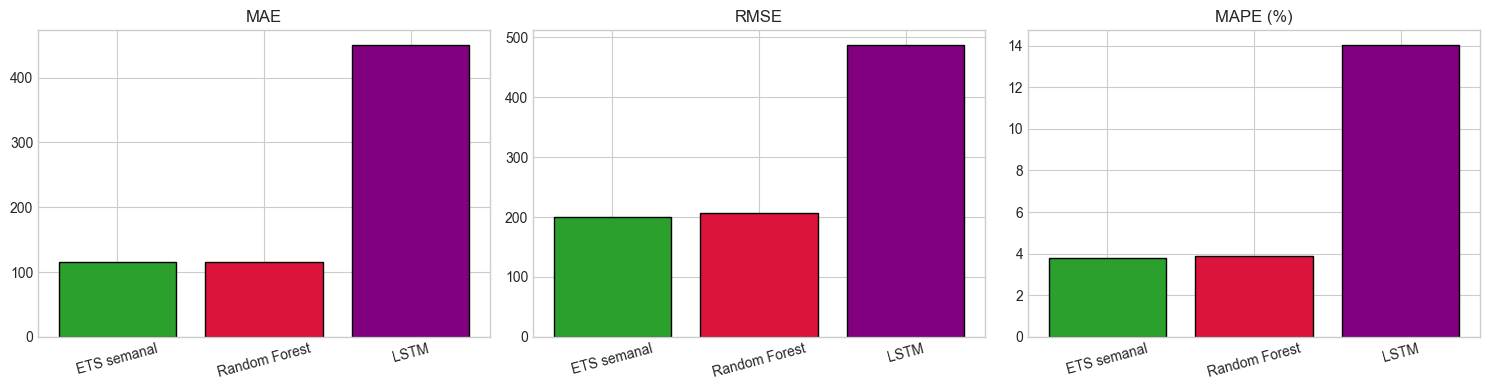

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(y_train.index[-365:], y_train.values[-365:], label="Train ultimos 365 dias", color="steelblue")
plt.plot(y_test.index, y_test.values, label="Test real", color="black", linewidth=2)
plt.plot(y_test.index, y_pred_rf, label="Random Forest", color="crimson", linewidth=2)
plt.plot(y_test.index, y_pred_ets, label="ETS semanal", color="seagreen", linewidth=2)
plt.plot(y_test.index, y_pred_lstm, label="LSTM", color="purple", linewidth=2)
plt.title("Predicciones sobre test holdout")
plt.ylabel("Volumen promedio diario")
plt.legend()
plt.savefig(FIGURES_DIR / "notebook_predicciones_test.png", dpi=160, bbox_inches="tight")
plt.show()

model_preds = [
    ("Random Forest", y_pred_rf, "crimson"),
    ("ETS semanal", y_pred_ets, "seagreen"),
    ("LSTM", y_pred_lstm, "purple"),
]
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for row, (name, pred, color) in enumerate(model_preds):
    residuals = y_test.values - pred
    axes[row, 0].plot(y_test.index, residuals, color=color)
    axes[row, 0].axhline(0, color="black", linewidth=1)
    axes[row, 0].set_title(f"Residuos {name}")
    plot_acf(pd.Series(residuals), lags=20, ax=axes[row, 1])
    axes[row, 1].set_title(f"ACF residuos {name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_residuos_modelos.png", dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
color_map = {"ETS semanal": "#2ca02c", "Random Forest": "crimson", "LSTM": "purple"}
for ax, metric, title in zip(axes, ["mae", "rmse", "mape"], ["MAE", "RMSE", "MAPE (%)"]):
    colors = [color_map[model] for model in final_metrics["modelo"]]
    ax.bar(final_metrics["modelo"], final_metrics[metric], color=colors, edgecolor="black")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_comparacion_modelos.png", dpi=160, bbox_inches="tight")
plt.show()

## 9) Respuestas y conclusiones

In [9]:
winner = final_metrics.iloc[0]
rf_row = final_metrics.loc[final_metrics["modelo"] == "Random Forest"].iloc[0]
ets_row = final_metrics.loc[final_metrics["modelo"] == "ETS semanal"].iloc[0]
lstm_row = final_metrics.loc[final_metrics["modelo"] == "LSTM"].iloc[0]

print("Pregunta 1 - Ventana de entrenamiento")
print(f"La mejor ventana para Random Forest fue: {best_window_label}.")
print(f"MAE promedio en backtesting: {float(res_window.sort_values('mae_mean').iloc[0]['mae_mean']):.2f}.")
print()
print("Pregunta 2 - Intervalo pasado como input")
print(f"El mejor intervalo para Random Forest fue: {best_lag_label}.")
print(f"MAE promedio en backtesting: {float(res_lags.sort_values('mae_mean').iloc[0]['mae_mean']):.2f}.")
print()
print("Modelo estadistico")
print(f"La mejor configuracion ETS fue: {best_ets_label}.")
print(f"MAE promedio en backtesting: {float(res_ets.sort_values('mae_mean').iloc[0]['mae_mean']):.2f}.")
print()
print("Modelo Deep Learning comparativo")
print("LSTM entrenado con secuencias de 28 dias sobre la serie diaria transformada con log1p.")
print()
print("Test final no usado para seleccion")
print(f"Random Forest - MAE: {rf_row['mae']:.2f} | RMSE: {rf_row['rmse']:.2f} | MAPE: {rf_row['mape']:.2f}%")
print(f"ETS semanal   - MAE: {ets_row['mae']:.2f} | RMSE: {ets_row['rmse']:.2f} | MAPE: {ets_row['mape']:.2f}%")
print(f"LSTM          - MAE: {lstm_row['mae']:.2f} | RMSE: {lstm_row['rmse']:.2f} | MAPE: {lstm_row['mape']:.2f}%")
print()
print(f"Mejor modelo por MAE en test: {winner['modelo']}.")
print("Fuga de datos evitada: split temporal, backtesting solo en train, lags con pasado, calendario conocido y test holdout separado.")

Pregunta 1 - Ventana de entrenamiento
La mejor ventana para Random Forest fue: todo_historico.
MAE promedio en backtesting: 217.29.

Pregunta 2 - Intervalo pasado como input
El mejor intervalo para Random Forest fue: 28_dias.
MAE promedio en backtesting: 214.16.

Modelo estadistico
La mejor configuracion ETS fue: ETS_NA.
MAE promedio en backtesting: 240.01.

Modelo Deep Learning comparativo
LSTM entrenado con secuencias de 28 dias sobre la serie diaria transformada con log1p.

Test final no usado para seleccion
Random Forest - MAE: 116.03 | RMSE: 206.83 | MAPE: 3.89%
ETS semanal   - MAE: 115.04 | RMSE: 200.29 | MAPE: 3.79%
LSTM          - MAE: 450.24 | RMSE: 487.55 | MAPE: 14.04%

Mejor modelo por MAE en test: ETS semanal.
Fuga de datos evitada: split temporal, backtesting solo en train, lags con pasado, calendario conocido y test holdout separado.


**Conclusiones.**

- El dataset cumple los requisitos: mas de 100 observaciones, columna temporal y variable numerica objetivo.
- Se evaluaron tres categorias: Machine Learning, estadistico y Deep Learning.
- Random Forest replica el enfoque del notebook original y permite comparar directamente.
- ETS semanal funciona como benchmark estadistico interpretable para una serie diaria con patron semanal.
- LSTM agrega el modelo Deep Learning sugerido en la guia y usa secuencias del pasado de la serie.
- La comparacion final se hace sobre el mismo test holdout de 45 dias.

## 10) Fuentes

- Dataset Kaggle: https://www.kaggle.com/datasets/anshtanwar/metro-interstate-traffic-volume
- KaggleHub: https://github.com/Kaggle/kagglehub
- scikit-learn RandomForestRegressor: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
- PyTorch LSTM: https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html
- statsmodels ExponentialSmoothing: https://www.statsmodels.org/